# 8 · Data association

**Recap** ([theory](https://github.com/Rudip1/learn-state-estimation/blob/main/1_theory/08_data_association.md)).
Readings arrive unlabelled. The nearest neighbour pairs by raw distance and ignores uncertainty. Individual
compatibility gates each pairing with its own innovation, $D^2_{ij} = \nu_{ij}^TS_{ij}^{-1}\nu_{ij} <
\chi^2_m(1-\alpha)$ with $S_{ij} = H_j\bar PH_j^T + R$, and ICNN takes the closest compatible feature. Because all
innovations depend on the same uncertain pose they are correlated; joint compatibility tests a whole hypothesis with
the stacked innovation and its full covariance, and JCBB searches for the hypothesis with the most jointly compatible
pairings.

In [1]:
# Installs the module when it is not available yet (e.g. on Colab). Building the C++ takes a few minutes.
try:
    import state_estimation
except ImportError:
    %pip install -q git+https://github.com/Rudip1/learn-state-estimation

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import state_estimation as se
from state_estimation import plotting

plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (6, 4.5)})

## The corridor example (§8.3)

Four landmarks 1 m apart; the robot believes it is at the origin with 1 m uncertainty along the corridor but is
0.9 m further on. Readings are landmark positions relative to the robot ($H = -I$).

In [3]:
landmarks_c = np.array([[float(j), 0.0] for j in range(4)])
P = np.diag([1.0, 0.01]); R = np.eye(2) * 0.01
noise = np.array([[-0.01, 0.0], [0.01, 0.005], [-0.01, 0.01], [0.01, 0.015]])
z = landmarks_c - np.array([0.9, 0.0]) + noise
problem = se.AssociationProblem(list(z), list(landmarks_c), [-np.eye(2)] * 4, P, R)
D2 = np.array([[se.individual_nis(problem, i, j) for j in range(4)] for i in range(4)])
print("individual NIS (rows: readings, columns: landmarks), gate", round(se.chi2_quantile(0.95, 2), 2))
print(D2.round(2))
for name, a in (("ICNN", se.associate_icnn(problem)), ("JCBB", se.associate_jcbb(problem))):
    nis, dof = se.joint_nis(problem, a.pairing)
    print(f"{name}: pairing {list(a.pairing)}, joint NIS {nis:.2f}, gate {se.chi2_quantile(0.95, dof):.2f}")

individual NIS (rows: readings, columns: landmarks), gate 5.99
[[8.200e-01 3.610e+00 8.380e+00 1.514e+01]
 [1.000e-02 7.900e-01 3.540e+00 8.270e+00]
 [1.180e+00 1.000e-02 8.200e-01 3.620e+00]
 [4.420e+00 1.230e+00 2.000e-02 8.000e-01]]
ICNN: pairing [0, 0, 1, 2], joint NIS 77.08, gate 15.51
JCBB: pairing [0, 1, 2, 3], joint NIS 0.86, gate 15.51


### ✏️ Exercise 1 — individual and joint NIS

Implement `individual_nis_np(z, zhat, H, P, R)` (eq. 8.2–8.4) and `joint_nis_np(problem, pairing)` (eq. 8.5–8.6),
building the stacked innovation, Jacobian and block-diagonal noise. Do not forget the cross-covariances: they come
for free from $H_\mathcal H\bar PH_\mathcal H^T$.

In [4]:
def individual_nis_np(z, zhat, H, P, R):
    ### BEGIN SOLUTION
    nu = z - zhat
    S = H @ P @ H.T + R
    return float(nu @ np.linalg.solve(S, nu))
    ### END SOLUTION

def joint_nis_np(problem, pairing):
    ### BEGIN SOLUTION
    pairs = [(i, j) for i, j in enumerate(pairing) if j >= 0]
    nu = np.concatenate([problem.observations[i] - problem.predictions[j] for i, j in pairs])
    H = np.vstack([problem.jacobians[j] for _, j in pairs])
    Rs = np.kron(np.eye(len(pairs)), problem.R)
    S = H @ problem.P @ H.T + Rs
    return float(nu @ np.linalg.solve(S, nu))
    ### END SOLUTION

In [5]:
for i in range(4):
    for j in range(4):
        assert np.isclose(individual_nis_np(z[i], landmarks_c[j], -np.eye(2), P, R), D2[i, j])
for pairing in ([0, 1, 2, 3], [0, 0, 1, 2], [-1, 0, 1, 2], [0, -1, 2, 3]):
    assert np.isclose(joint_nis_np(problem, pairing), se.joint_nis(problem, pairing)[0])
print("✔ both match; joint NIS of the ICNN hypothesis without reading 0:", round(joint_nis_np(problem, [-1, 0, 1, 2]), 2))

✔ both match; joint NIS of the ICNN hypothesis without reading 0: 0.05


### ✏️ Exercise 2 — exhaustive search

For small problems the best hypothesis can be found by trying them all. Write `best_hypothesis(problem, alpha)`
that enumerates every one-to-one assignment (each reading to a feature or to −1, no feature used twice), keeps those
whose pairings are all individually compatible and that are jointly compatible, and returns the one with the most
pairings (ties: smallest joint NIS). It must agree with JCBB.

In [6]:
import itertools

def best_hypothesis(problem, alpha=0.05):
    ### BEGIN SOLUTION
    n, N = problem.n_observations, problem.n_features
    ic_gate = se.chi2_quantile(1 - alpha, 2)
    best, best_key = [-1] * n, (0, 0.0)
    for h in itertools.product(range(-1, N), repeat=n):
        used = [j for j in h if j >= 0]
        if len(used) != len(set(used)) or not used:
            continue
        if any(se.individual_nis(problem, i, j) > ic_gate for i, j in enumerate(h) if j >= 0):
            continue
        nis, dof = se.joint_nis(problem, list(h))
        if nis > se.chi2_quantile(1 - alpha, dof):
            continue
        key = (len(used), -nis)
        if key > best_key:
            best, best_key = list(h), key
    return best
    ### END SOLUTION

In [7]:
assert best_hypothesis(problem) == list(se.associate_jcbb(problem).pairing)
rng = se.Rng(1); wide = se.RangeBearingSensor(20, 2 * np.pi, 0.1, 0.03)
for _ in range(10):
    lm = np.array([[rng.uniform(-4, 4), rng.uniform(-4, 4)] for _ in range(4)])
    xb, Pb = np.zeros(3), np.diag([0.3, 0.3, 0.05])
    obs = se.add_clutter(wide.observe(se.sample_gaussian(xb, Pb, 1, rng)[0], lm, rng)[:2], 1, wide, rng)
    p = se.landmark_association_problem(xb, Pb, obs, lm, wide.R())
    assert best_hypothesis(p) == list(se.associate_jcbb(p).pairing)
print("✔ JCBB finds the best hypothesis")

✔ JCBB finds the best hypothesis


## EKF localisation with unknown correspondences

A grid of 25 landmarks (2 m spacing, slightly perturbed), a sensor with 3 m range: every scan is ambiguous unless the
pose is known well. The EKF of chapter 6 now associates each scan itself and updates with the paired readings.

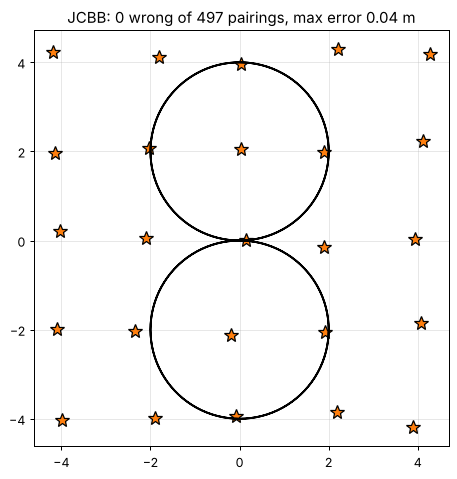

In [8]:
gx, gy = np.meshgrid(np.arange(-4, 5, 2.0), np.arange(-4, 5, 2.0))
landmarks = np.c_[gx.ravel(), gy.ravel()] + np.random.default_rng(0).normal(0, 0.15, (gx.size, 2))
dd, dt = se.DifferentialDrive(0.1, 0.5), 0.1
sensor = se.RangeBearingSensor(3.0, np.deg2rad(180), 0.05, 0.02)
u = np.vstack([se.figure_eight_controls(2.0, 200, dt)] * 2)
methods = {"NN (0.5)": lambda p: se.associate_nearest_neighbor(p, 0.5),
           "ICNN": lambda p: se.associate_icnn(p),
           "JCBB": lambda p: se.associate_jcbb(p)}

def localise(method, k, every, clutter, seed):
    r = se.simulate_landmark_run(np.zeros(3), u, dt, dd, k, sensor, landmarks, every, se.Rng(seed))
    rng = se.Rng(seed + 100)
    f = se.EkfLocalization(np.zeros(3), np.diag([1e-4, 1e-4, 1e-5]))
    wrong = total = 0; err = []
    for s, (dl, dr) in enumerate(r.wheel_travel):
        f.predict_wheels(dd, dl, dr, k * abs(dl), k * abs(dr))
        if r.scans[s]:
            obs = se.add_clutter(r.scans[s], clutter, sensor, rng)
            a = methods[method](se.landmark_association_problem(f.pose, f.covariance, obs, landmarks, sensor.R()))
            paired = [se.Observation(j, o.z) for o, j in zip(obs, a.pairing) if j >= 0]
            total += len(paired); wrong += sum(o.landmark != j for o, j in zip(obs, a.pairing) if j >= 0)
            f.update_landmarks(paired, landmarks, sensor.R())
        err.append(np.linalg.norm(f.pose[:2] - r.truth[s + 1, :2]))
    return wrong, total, np.array(err), r

wrong, total, err, r = localise("JCBB", 2e-4, 5, 0, 0)
ax = plotting.new_axes(figsize=(6, 6))
ax.plot(landmarks[:, 0], landmarks[:, 1], "*", color="C1", ms=12, mec="k")
plotting.plot_trajectory(ax, r.truth, "truth", "k")
ax.set_title(f"JCBB: {wrong} wrong of {total} pairings, max error {err.max():.2f} m"); plt.show()

## 🔨 Break it — clutter

Add two spurious readings to every scan. The Euclidean nearest neighbour pairs them with whatever landmark is
closest; the gated methods reject most of them, JCBB almost all.

In [9]:
for name in methods:
    res = [localise(name, 2e-4, 5, 2, s) for s in range(5)]
    w_, t_ = sum(x[0] for x in res), sum(x[1] for x in res)
    print(f"{name:9s}: {w_:4d} wrong of {t_:5d} pairings, max error per run {[round(float(x[2].max()), 2) for x in res]}")

NN (0.5) :  418 wrong of  3038 pairings, max error per run [0.09, 0.14, 0.17, 0.13, 0.11]


ICNN     :   21 wrong of  2479 pairings, max error per run [0.04, 0.07, 0.04, 0.21, 0.04]


JCBB     :    4 wrong of  2448 pairings, max error per run [0.04, 0.07, 0.04, 0.21, 0.04]


## 🔨 Break it — too much drift between scans

Now the encoders are ten times noisier and the robot only scans every 20 steps. Between scans the pose uncertainty
grows to the size of the landmark spacing and the grid becomes ambiguous for every method. The $\chi^2$ gates grow
with the covariance and admit wrong candidates; JCBB makes fewer wrong pairings than ICNN, and here the
conservative fixed 0.5 m radius of NN happens to make the fewest. Once a wrong hypothesis is accepted the covariance
shrinks around a wrong pose and no association method can recover: some runs end metres away. Data association
cannot replace sufficient sensing.

In [10]:
for name in methods:
    res = [localise(name, 2e-3, 20, 0, s) for s in range(5)]
    w_, t_ = sum(x[0] for x in res), sum(x[1] for x in res)
    print(f"{name:9s}: {w_:4d} wrong of {t_:4d} pairings, final error per run {[round(float(x[2][-1]), 2) for x in res]}")

NN (0.5) :   18 wrong of  604 pairings, final error per run [0.06, 2.87, 0.04, 0.04, 0.02]

ICNN     :   56 wrong of  458 pairings, final error per run [0.02, 2.67, 0.03, 2.26, 3.88]


JCBB     :   33 wrong of  453 pairings, final error per run [0.02, 2.71, 0.03, 0.04, 2.64]

## What to remember

- Gate with the Mahalanobis distance, never a fixed Euclidean radius.
- Innovations of one scan are correlated through the pose: test them jointly.
- JCBB maximises the number of jointly compatible pairings and rejects clutter, at a small cost when the robot is well
  localised.
- One accepted wrong pairing makes the filter confidently wrong; association needs the pose uncertainty to stay small
  compared with the spacing of the features.